# Deliverable 2: Fashion Parsing

## 1. Install and Import Dependencies

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import defaultdict

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print("All imports OK")

All imports OK


## 2. Configuration Ã¢â‚¬â€œ Set Your Paths Here

In [2]:
# Path to the Fashionpedia TRAIN JSON annotation file
ANNO_JSON_PATH = "data/instances_attributes_train2020.json"

# Directory containing the PNG segmentation maps produced by fashionpedia.py
# Each file is named <image_stem>_seg.png
SEG_PNG_DIR = "data/segmentations_train/"

assert os.path.exists(ANNO_JSON_PATH), f"JSON not found: {ANNO_JSON_PATH}"
assert os.path.isdir(SEG_PNG_DIR),     f"Segmentation dir not found: {SEG_PNG_DIR}"
print(f"JSON : {ANNO_JSON_PATH}")
print(f"PNGs : {SEG_PNG_DIR}")

JSON : data/instances_attributes_train2020.json
PNGs : data/segmentations_train/


## 3. Load Annotations and Build Category Map

In [4]:
with open(ANNO_JSON_PATH, 'r') as f:
    annotation_data = json.load(f)

# category_id -> category_name  (IDs 0..45 in the JSON)
# In the segmentation PNGs, pixel_value = category_id + 1 (so 0 = background)
category_id_to_name = {category['id']: category['name'] for category in annotation_data['categories']}
category_ids   = sorted(category_id_to_name.keys())   # sorted label indices (0, 1, 2, ...)
category_names = [category_id_to_name[cid] for cid in category_ids]

# image_id -> image metadata
img_id_to_info = {img['id']: img for img in annotation_data['images']}

print(f"Number of categories : {len(category_ids)}")
print(f"Number of images     : {len(img_id_to_info)}")
print(f"Number of annotations: {len(annotation_data['annotations'])}")
print("\nCategory list (label index -> name):")
for category_id in category_ids:
    print(f"  [{category_id}] {category_id_to_name[category_id]}")

Number of categories : 46
Number of images     : 45623
Number of annotations: 333401

Category list (label index -> name):
  [0] shirt, blouse
  [1] top, t-shirt, sweatshirt
  [2] sweater
  [3] cardigan
  [4] jacket
  [5] vest
  [6] pants
  [7] shorts
  [8] skirt
  [9] coat
  [10] dress
  [11] jumpsuit
  [12] cape
  [13] glasses
  [14] hat
  [15] headband, head covering, hair accessory
  [16] tie
  [17] glove
  [18] watch
  [19] belt
  [20] leg warmer
  [21] tights, stockings
  [22] sock
  [23] shoe
  [24] bag, wallet
  [25] scarf
  [26] umbrella
  [27] hood
  [28] collar
  [29] lapel
  [30] epaulette
  [31] sleeve
  [32] pocket
  [33] neckline
  [34] buckle
  [35] zipper
  [36] applique
  [37] bead
  [38] bow
  [39] flower
  [40] fringe
  [41] ribbon
  [42] rivet
  [43] ruffle
  [44] sequin
  [45] tassel


## 4. Iterate Over PNG Segmentation Maps and Collect Statistics

Each PNG pixel value equals `category_id + 1` (0 = background, 1 = category 0, Ã¢â‚¬Â¦, 46 = category 45).  
We read every segmentation PNG and accumulate per-label pixel counts.

In [6]:
def get_seg_png(img_info, seg_dir):
    img_stem = os.path.splitext(img_info['file_name'])[0]
    path = os.path.join(seg_dir, f"{img_stem}_seg.png")
    return path if os.path.exists(path) else None

In [ ]:
per_label_data = {category_id: {'ratio_full': [], 'ratio_foreground': []} for category_id in category_ids}

for img_id, img_info in img_id_to_info.items():
    seg_path = get_seg_png(img_info, SEG_PNG_DIR)

    if seg_path is None:
        raise Exception("File not found.", img_info)

    # Load PNG (H, W, 1)
    seg = np.array(Image.open(seg_path))

    total_pixels = seg.size
    fg_pixels    = int((seg > 0).sum())   # foreground = any non-background pixel

    labels_present, counts = np.unique(seg, return_counts=True)

    for label, count in zip(labels_present.tolist(), counts.tolist()):
        # skip background
        if label == 0:
            continue    

        # fashionpedia.py stores category_id + 1
        cat_id = label - 1                

        per_label_data[cat_id]['ratio_full'].append(count / total_pixels)
        per_label_data[cat_id]['ratio_fg'].append(count / fg_pixels)



## 5. Build Summary DataFrame

In [ ]:
rows = []
for category_id in category_ids:
    ratio_full = np.array(per_label_data[category_id]['ratio_full'])
    ratio_foreground = np.array(per_label_data[category_id]['ratio_foreground'])
    images_count  = len(ratio_full)
    rows.append({
        'category_id'    : category_id,
        'category_name'  : category_id_to_name[category_id],
        'num_images'     : images_count,
        'mean_ratio_full': float(ratio_full.mean()),
        'var_ratio_full' : float(ratio_full.var()),
        'mean_ratio_foreground'  : float(ratio_foreground.mean()),
        'var_ratio_foreground'   : float(ratio_foreground.var()),
    })

df = pd.DataFrame(rows)

fmt = lambda x: f"{x:.5f}" if pd.notna(x) else 'N/A'
print(df[['category_name','num_images','mean_ratio_full','var_ratio_full',
          'mean_ratio_foreground','var_ratio_foreground']].to_string(index=False, formatters={
    'mean_ratio_full': fmt, 'var_ratio_full': fmt,
    'mean_ratio_foreground'  : fmt, 'var_ratio_foreground'  : fmt,
}))

df.to_csv('label_distribution_stats.csv', index=False)
print("Saved -> label_distribution_stats.csv")

                          category_name  num_images mean_ratio_full var_ratio_full mean_ratio_foreground var_ratio_foreground
                          shirt, blouse        6084         0.06641        0.01027               0.24180              0.05675
               top, t-shirt, sweatshirt       16102         0.08892        0.01507               0.35085              0.07351
                                sweater        1480         0.15131        0.02084               0.42870              0.06006
                               cardigan        1101         0.10723        0.01914               0.32496              0.04716
                                 jacket        7741         0.07519        0.00630               0.29726              0.02025
                                   vest         717         0.05989        0.00731               0.26805              0.05108
                                  pants       12346         0.07040        0.00457               0.36489              

## 6. Plot: Number of Images per Label

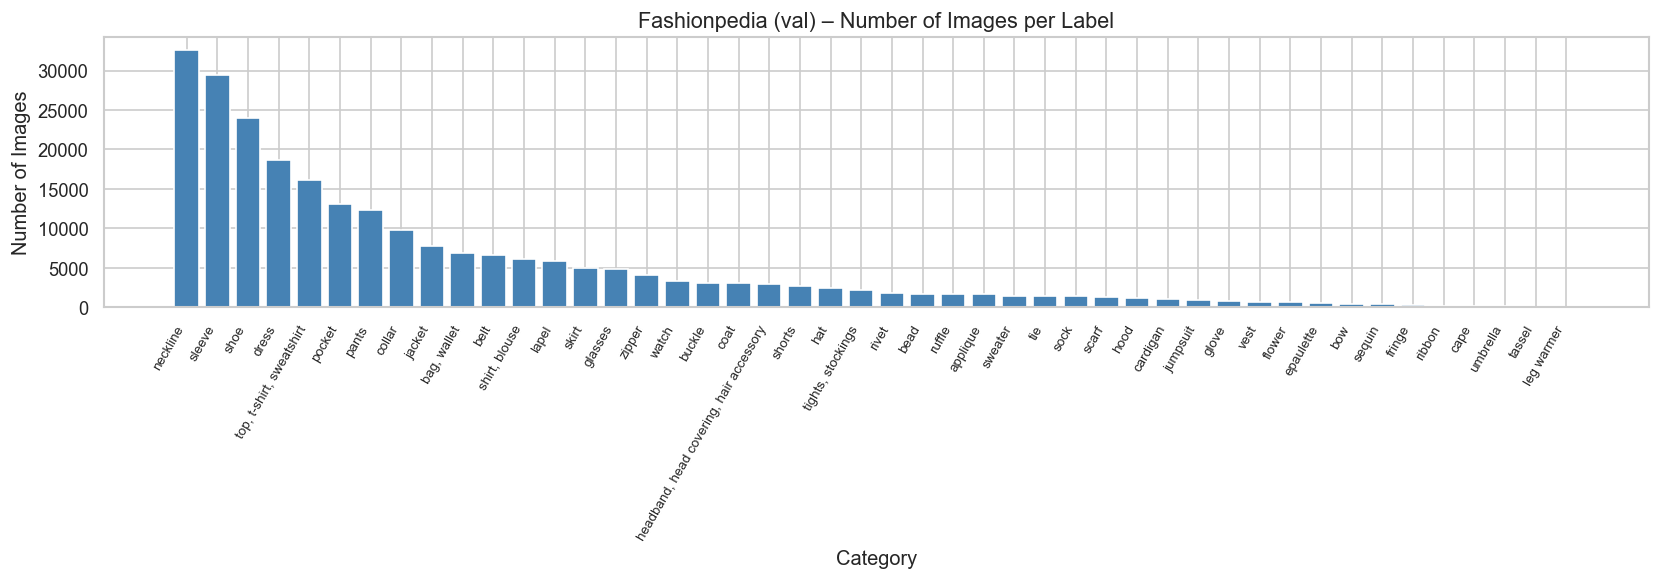

Saved -> plots/images_per_label.png


In [24]:
df_sorted_imgs = df.sort_values('num_images', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(df_sorted_imgs['category_name'], df_sorted_imgs['num_images'],
       color='steelblue', edgecolor='white')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Fashionpedia (val) Ã¢â‚¬â€œ Number of Images per Label', fontsize=13)
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('plots/images_per_label.png', bbox_inches='tight')
plt.show()
print("Saved -> plots/images_per_label.png")

## 7. Plot: Pixel Ratio Statistics (ratio_full and ratio_fg)

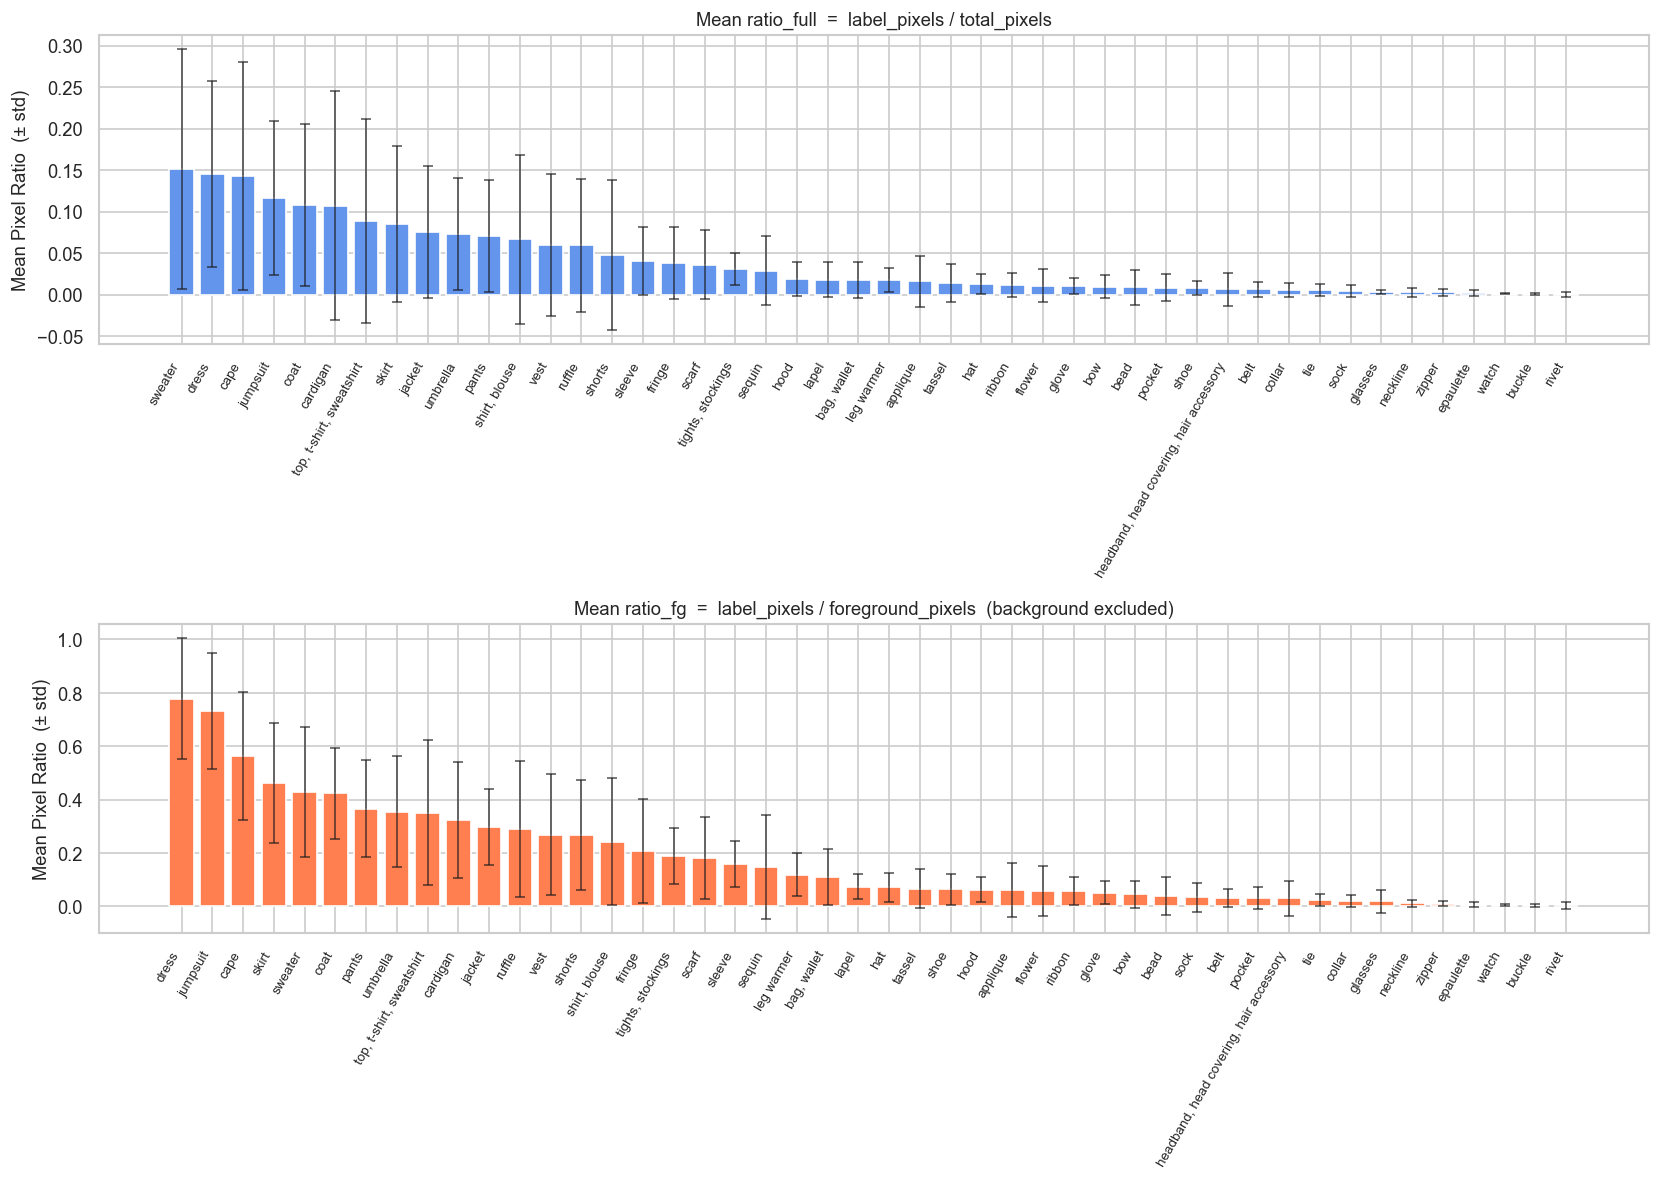

Saved -> plots/pixel_ratio_per_label.png


In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, metric, color, title in [
    (axes[0], 'ratio_full', 'cornflowerblue',
     'Mean ratio_full  =  label_pixels / total_pixels'),
    (axes[1], 'ratio_foreground',   'coral',
     'Mean ratio_fg  =  label_pixels / foreground_pixels  (background excluded)'),
]:
    df_s  = df.sort_values(f'mean_{metric}', ascending=False)
    x     = np.arange(len(df_s))
    means = df_s[f'mean_{metric}'].values
    stds  = np.sqrt(df_s[f'var_{metric}'].values)

    ax.bar(x, means, yerr=stds, color=color, capsize=3,
           edgecolor='white', error_kw={'elinewidth': 1, 'alpha': 0.7})
    ax.set_xticks(x)
    ax.set_xticklabels(df_s['category_name'], rotation=60, ha='right', fontsize=8)
    ax.set_ylabel('Mean Pixel Ratio  (Ã‚Â± std)', fontsize=11)
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig('plots/pixel_ratio_per_label.png', bbox_inches='tight')
plt.show()
print("Saved -> plots/pixel_ratio_per_label.png")

## 8. Combined 3-Panel Summary

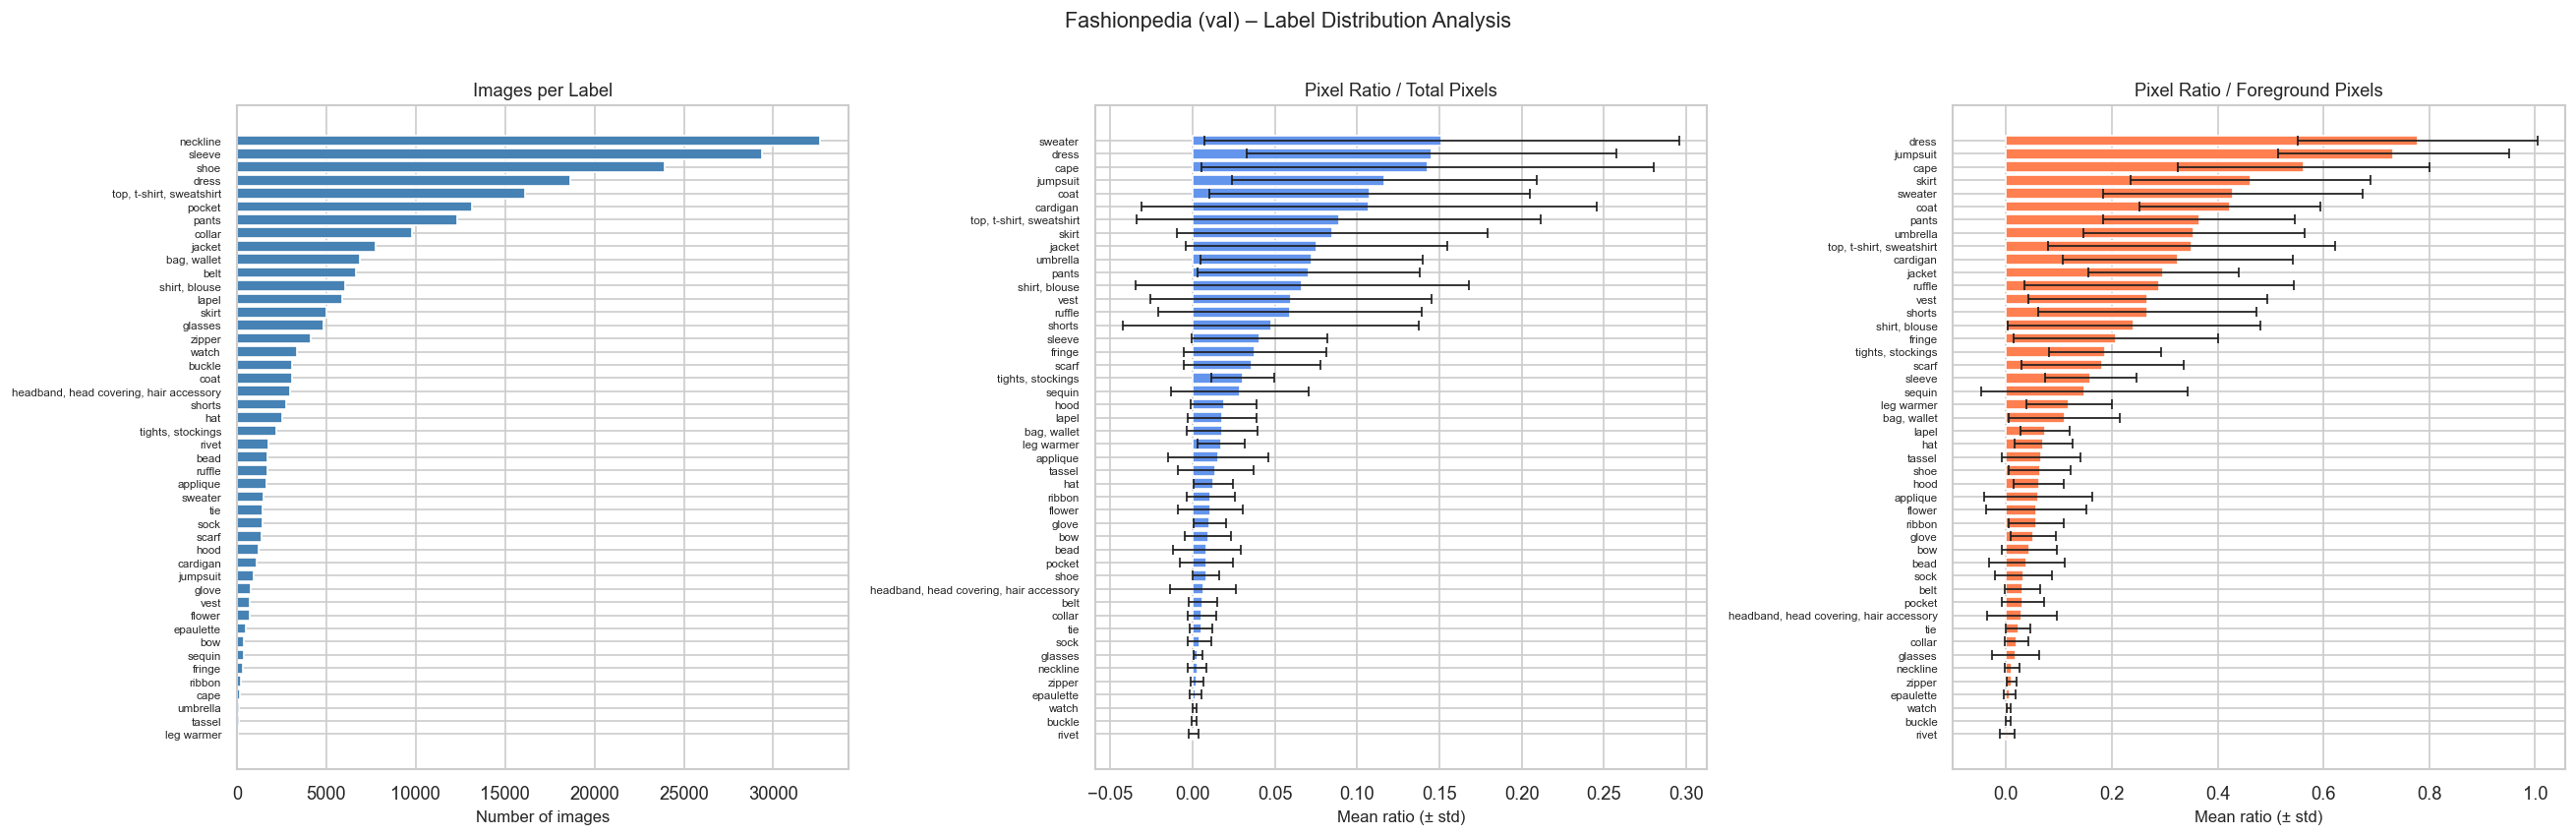

Saved -> plots/label_distribution_summary.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, sort_col, val_col, err_col, color, xlabel, title in [
    (axes[0], 'num_images',      'num_images',      None,
     'steelblue',      'Number of images',  'Images per Label'),
    (axes[1], 'mean_ratio_full', 'mean_ratio_full', 'var_ratio_full',
     'cornflowerblue', 'Mean ratio (Ã‚Â± std)', 'Pixel Ratio / Total Pixels'),
    (axes[2], 'mean_ratio_foreground',   'mean_ratio_foreground',   'var_ratio_foreground',
     'coral',          'Mean ratio (Ã‚Â± std)', 'Pixel Ratio / Foreground Pixels'),
]:
    df_s = df.sort_values(sort_col, ascending=False)
    vals = df_s[val_col].values
    errs = np.sqrt(df_s[err_col].values) if err_col else None

    ax.barh(df_s['category_name'], vals, xerr=errs,
            color=color, capsize=3, error_kw={'elinewidth': 1})
    ax.invert_yaxis()
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Fashionpedia (val) Ã¢â‚¬â€œ Label Distribution Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plots/label_distribution_summary.png', bbox_inches='tight')
plt.show()
print("Saved -> plots/label_distribution_summary.png")

## 9. Top-10 Most and Least Dominant Labels

In [22]:
df_valid = df.dropna(subset=['mean_ratio_full'])

print("Top-10 most dominant labels (mean ratio_full):")
print(df_valid.nlargest(10, 'mean_ratio_full')
      [['category_name','num_images','mean_ratio_full','var_ratio_full']]
      .to_string(index=False))

print("\nTop-10 least dominant labels (mean ratio_full):")
print(df_valid.nsmallest(10, 'mean_ratio_full')
      [['category_name','num_images','mean_ratio_full','var_ratio_full']]
      .to_string(index=False))

Top-10 most dominant labels (mean ratio_full):
           category_name  num_images  mean_ratio_full  var_ratio_full
                 sweater        1480         0.151314        0.020842
                   dress       18664         0.145040        0.012620
                    cape         152         0.142893        0.018943
                jumpsuit         922         0.116494        0.008549
                    coat        3084         0.107656        0.009497
                cardigan        1101         0.107231        0.019136
top, t-shirt, sweatshirt       16102         0.088920        0.015070
                   skirt        5029         0.085004        0.008927
                  jacket        7741         0.075195        0.006305
                umbrella         134         0.072486        0.004557

Top-10 least dominant labels (mean ratio_full):
category_name  num_images  mean_ratio_full  var_ratio_full
        rivet        1760         0.000490    8.987047e-06
       buckle   

## 10. Deliverable 2 - Part 2: Final MMSegmentation Workflow

This section supersedes the earlier draft and follows the final agreed plan exactly:

- compare `DeepLabV3+`, `SegFormer`, and `UPerNet`
- run both `192x192` and `384x384`
- tune learning rate and batch size factor-by-factor
- apply one shared augmentation pipeline to all runs
- select the best model and best resolution
- remove the top-5 dominant labels and repeat the tuning loop on the reduced-label dataset

The notebook section below delegates the experiment-building logic to `fashion_mmseg_utils.py` and the custom strong augmentations to `fashion_mmseg_transforms.py`.

In [1]:
from pathlib import Path
import pandas as pd

from fashion_mmseg_utils import (
    build_reduced_label_experiments,
    build_reduced_label_mapping,
    build_resolution_delta_table,
    build_split_manifest,
    build_stage1_lr_sweep,
    build_stage2_batch_sweep,
    build_stage4_final_confirmation,
    build_train_command,
    collect_scalar_metrics,
    export_reduced_masks,
    generate_config_text,
    load_fashionpedia_classes,
    pick_dominant_labels,
    sample_manifest,
    summarize_model_choices,
    write_config_file,
    write_experiment_manifest,
    write_manifest_artifacts,
)

PROJECT_ROOT = Path.cwd().resolve()
ARTIFACTS_DIR = PROJECT_ROOT / "mmseg_artifacts"
CONFIGS_DIR = PROJECT_ROOT / "mmseg_generated_configs"
WORK_DIR = PROJECT_ROOT / "mmseg_workdirs"

for path in [ARTIFACTS_DIR, CONFIGS_DIR, WORK_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(summarize_model_choices().to_string(index=False))

            model           display_name      family                                                                                          justification
deeplabv3plus_r50 DeepLabV3+ (ResNet-50)         cnn                                  Strong CNN baseline, stable, widely used, and a good reference point.
 segformer_mit-b0     SegFormer (MiT-B0) transformer                Modern transformer-style lightweight model with a strong efficiency/accuracy trade-off.
upernet_swin-tiny    UPerNet (Swin-Tiny) transformer Stronger hierarchical transformer model that complements SegFormer and usually offers higher capacity.


In [2]:
# Update these paths before running the experiment pipeline.
# In this project, the validation images referenced by
# instances_attributes_val2020.json live under data/test.
TRAIN_JSON_PATH = PROJECT_ROOT / "data" / "instances_attributes_train2020.json"
VAL_JSON_PATH = PROJECT_ROOT / "data" / "instances_attributes_val2020.json"
TRAIN_IMAGE_DIR = PROJECT_ROOT / "data" / "train"
VAL_IMAGE_DIR = PROJECT_ROOT / "data" / "test"
TRAIN_MASK_DIR = PROJECT_ROOT / "data" / "segmentations_train"
VAL_MASK_DIR = PROJECT_ROOT / "data" / "segmentations_val"
MMSEG_ROOT = PROJECT_ROOT / "mmsegmentation"

assert TRAIN_JSON_PATH.exists(), f"Missing train json: {TRAIN_JSON_PATH}"
assert VAL_JSON_PATH.exists(), f"Missing val json: {VAL_JSON_PATH}"
assert TRAIN_IMAGE_DIR.exists(), f"Missing train image dir: {TRAIN_IMAGE_DIR}"
assert VAL_IMAGE_DIR.exists(), f"Missing val image dir: {VAL_IMAGE_DIR}"
assert TRAIN_MASK_DIR.exists(), f"Missing train mask dir: {TRAIN_MASK_DIR}"
assert VAL_MASK_DIR.exists(), f"Missing val mask dir: {VAL_MASK_DIR}"
assert MMSEG_ROOT.exists(), f"Missing mmsegmentation clone: {MMSEG_ROOT}"

# Laptop smoke-test toggles.
DEBUG_SMALL_RUN = True
DEBUG_TRAIN_FRACTION = 0.02
DEBUG_VAL_FRACTION = 0.10
DEBUG_MAX_TRAIN = 200
DEBUG_MAX_VAL = 80
DEBUG_ONLY_ONE_MODEL = None  # Example: 'segformer_mit-b0'
DEBUG_ONLY_ONE_RESOLUTION = None  # Example: (192, 192)

CLASSES, PALETTE, categories_df = load_fashionpedia_classes(TRAIN_JSON_PATH)
train_manifest_df = build_split_manifest(TRAIN_JSON_PATH, TRAIN_IMAGE_DIR, TRAIN_MASK_DIR, "train")
val_manifest_df = build_split_manifest(VAL_JSON_PATH, VAL_IMAGE_DIR, VAL_MASK_DIR, "val")

if DEBUG_SMALL_RUN:
    train_manifest_df = sample_manifest(
        train_manifest_df,
        fraction=DEBUG_TRAIN_FRACTION,
        max_items=DEBUG_MAX_TRAIN,
        random_seed=42,
    )
    val_manifest_df = sample_manifest(
        val_manifest_df,
        fraction=DEBUG_VAL_FRACTION,
        max_items=DEBUG_MAX_VAL,
        random_seed=42,
    )
    manifest_paths = write_manifest_artifacts(train_manifest_df, val_manifest_df, ARTIFACTS_DIR / "debug_dataset")
else:
    manifest_paths = write_manifest_artifacts(train_manifest_df, val_manifest_df, ARTIFACTS_DIR / "full_dataset")

image_suffixes = sorted(set(train_manifest_df["image_suffix"]).union(set(val_manifest_df["image_suffix"])))
assert len(image_suffixes) == 1, f"Expected a single image suffix, found: {image_suffixes}"
IMAGE_SUFFIX = image_suffixes[0]

dominant_labels_df = pick_dominant_labels(PROJECT_ROOT / "label_distribution_stats.csv", top_k=5)
reduced_mapping_df = build_reduced_label_mapping(categories_df, dominant_labels_df["category_id"].tolist())
reduced_mapping_path = ARTIFACTS_DIR / "reduced_label_mapping.csv"
reduced_mapping_df.to_csv(reduced_mapping_path, index=False)

print(f"Debug small run: {DEBUG_SMALL_RUN}")
print(f"Train samples: {len(train_manifest_df)}")
print(f"Val samples: {len(val_manifest_df)}")
print(f"Classes including background: {len(CLASSES)}")
print(f"Image suffix: {IMAGE_SUFFIX}")
display(dominant_labels_df[["category_id", "category_name", "mean_ratio_full", "mask_value"]])
display(reduced_mapping_df.head(10))

Debug small run: True
Train samples: 200
Val samples: 80
Classes including background: 47
Image suffix: .jpg


,category_id,category_name,mean_ratio_full,mask_value
0,2,sweater,0.151314,3
1,10,dress,0.145040,11
2,12,cape,0.142893,13
3,11,jumpsuit,0.116494,12
4,9,coat,0.107656,10


,original_category_id,original_mask_value,category_name,status,new_mask_value
0,-1,0,background,kept,0
1,0,1,"shirt, blouse",kept,1
2,1,2,"top, t-shirt, sweatshirt",kept,2
3,2,3,sweater,ignored,255
4,3,4,cardigan,kept,3
5,4,5,jacket,kept,4
6,5,6,vest,kept,5
7,6,7,pants,kept,6
8,7,8,shorts,kept,7
9,8,9,skirt,kept,8


In [3]:
if DEBUG_SMALL_RUN:
    RANKING_ITERS = 100
    FINAL_ITERS = 300
    VAL_INTERVAL = 50
else:
    RANKING_ITERS = 4000
    FINAL_ITERS = 12000
    VAL_INTERVAL = 1000

def make_experiment_name(row):
    resolution = f"{row['resolution'][0]}x{row['resolution'][1]}"
    lr_token = str(row['lr']).replace("-", "m").replace(".", "p")
    batch_token = "auto" if pd.isna(row['batch_size']) else f"bs{int(row['batch_size'])}"
    return f"{row['phase']}__{row['label_set']}__{row['model']}__{resolution}__lr{lr_token}__{batch_token}__{row['augmentation_branch']}__{row['schedule']}"

def get_active_classes_and_palette(label_set):
    if label_set == "full":
        return CLASSES, PALETTE

    kept_df = reduced_mapping_df[reduced_mapping_df["status"] == "kept"].copy()
    active_classes = kept_df["category_name"].tolist()
    active_palette = PALETTE[:len(active_classes)]
    return active_classes, active_palette

def materialize_configs(experiments_df, train_manifest_path, train_image_dir, train_mask_dir, val_manifest_path, val_image_dir, val_mask_dir, label_set, max_iters):
    rows = []
    active_classes, active_palette = get_active_classes_and_palette(label_set)

    for row in experiments_df.to_dict("records"):
        experiment_name = make_experiment_name(row)
        config_path = CONFIGS_DIR / f"{experiment_name}.py"
        work_dir = WORK_DIR / experiment_name

        batch_size = 4 if pd.isna(row["batch_size"]) else int(row["batch_size"])
        config_text = generate_config_text(
            mmseg_root=MMSEG_ROOT,
            project_root=PROJECT_ROOT,
            model_key=row["model"],
            experiment_name=experiment_name,
            train_image_dir=str(Path(train_image_dir).resolve()),
            train_mask_dir=str(Path(train_mask_dir).resolve()),
            val_image_dir=str(Path(val_image_dir).resolve()),
            val_mask_dir=str(Path(val_mask_dir).resolve()),
            train_split_file=str((Path(train_manifest_path).parent / "train.txt").resolve()),
            val_split_file=str((Path(val_manifest_path).parent / "val.txt").resolve()),
            train_manifest_path=str(Path(train_manifest_path).resolve()),
            img_suffix=IMAGE_SUFFIX,
            classes=active_classes,
            palette=active_palette,
            resolution=row["resolution"],
            lr=row["lr"],
            batch_size=batch_size,
            augmentation_branch=row["augmentation_branch"],
            max_iters=max_iters,
            val_interval=VAL_INTERVAL,
            work_dir=str(work_dir.resolve()),
        )

        write_config_file(config_text, config_path)
        rows.append({
            **row,
            "experiment_name": experiment_name,
            "config_path": str(config_path.resolve()),
            "train_command": build_train_command(mmseg_root=MMSEG_ROOT, project_root=PROJECT_ROOT, config_path=config_path),
        })

    return pd.DataFrame(rows)

stage1_lr_df = build_stage1_lr_sweep(schedule_name="ranking_short")
if DEBUG_ONLY_ONE_MODEL is not None:
    stage1_lr_df = stage1_lr_df[stage1_lr_df["model"] == DEBUG_ONLY_ONE_MODEL].reset_index(drop=True)
if DEBUG_ONLY_ONE_RESOLUTION is not None:
    stage1_lr_df = stage1_lr_df[stage1_lr_df["resolution"].apply(tuple) == tuple(DEBUG_ONLY_ONE_RESOLUTION)].reset_index(drop=True)
stage1_lr_runs = materialize_configs(
    stage1_lr_df,
    manifest_paths["train_manifest"],
    TRAIN_IMAGE_DIR,
    TRAIN_MASK_DIR,
    manifest_paths["val_manifest"],
    VAL_IMAGE_DIR,
    VAL_MASK_DIR,
    label_set="full",
    max_iters=RANKING_ITERS,
)

stage1_manifest_path = write_experiment_manifest(stage1_lr_runs, ARTIFACTS_DIR / "stage1_lr_manifest.csv")
display(stage1_lr_runs[["model", "resolution", "lr", "batch_size", "config_path"]].head())
print(f"Stage 1 manifest: {stage1_manifest_path}")

,model,resolution,lr,batch_size,config_path
0,deeplabv3plus_r50,"(192, 192)",0.00003,None,C:\Users\Daniel\Documents\Masters\S2\OR\Fashio...
1,deeplabv3plus_r50,"(192, 192)",0.00010,None,C:\Users\Daniel\Documents\Masters\S2\OR\Fashio...
2,deeplabv3plus_r50,"(192, 192)",0.00030,None,C:\Users\Daniel\Documents\Masters\S2\OR\Fashio...
3,deeplabv3plus_r50,"(384, 384)",0.00003,None,C:\Users\Daniel\Documents\Masters\S2\OR\Fashio...
4,deeplabv3plus_r50,"(384, 384)",0.00010,None,C:\Users\Daniel\Documents\Masters\S2\OR\Fashio...


Stage 1 manifest: C:\Users\Daniel\Documents\Masters\S2\OR\Fashion_Segmentation\mmseg_artifacts\stage1_lr_manifest.csv


In [ ]:
# Fill these dictionaries after each stage using the best validation mDice for each model/resolution pair.

BEST_LR_BY_MODEL_RES = {
    # ("deeplabv3plus_r50", (192, 192)): 1e-4,
}

BEST_PARAMS_BY_MODEL_RES = {
    # ("segformer_mit-b0", (384, 384)): {"lr": 1e-4, "batch_size": 8},
}

FINAL_PARAMS_BY_MODEL_RES = {
    # ("segformer_mit-b0", (384, 384)): {"lr": 1e-4, "batch_size": 8},
}

if BEST_LR_BY_MODEL_RES:
    stage2_batch_df = build_stage2_batch_sweep(BEST_LR_BY_MODEL_RES, schedule_name="ranking_short")
    stage2_batch_runs = materialize_configs(
        stage2_batch_df,
        manifest_paths["train_manifest"],
        TRAIN_IMAGE_DIR,
        TRAIN_MASK_DIR,
        manifest_paths["val_manifest"],
        VAL_IMAGE_DIR,
        VAL_MASK_DIR,
        label_set="full",
        max_iters=RANKING_ITERS,
    )
    write_experiment_manifest(stage2_batch_runs, ARTIFACTS_DIR / "stage2_batch_manifest.csv")
    display(stage2_batch_runs[["model", "resolution", "lr", "batch_size"]].head())

if FINAL_PARAMS_BY_MODEL_RES:
    stage4_final_df = build_stage4_final_confirmation(FINAL_PARAMS_BY_MODEL_RES, schedule_name="final_long")
    stage4_final_runs = materialize_configs(
        stage4_final_df,
        manifest_paths["train_manifest"],
        TRAIN_IMAGE_DIR,
        TRAIN_MASK_DIR,
        manifest_paths["val_manifest"],
        VAL_IMAGE_DIR,
        VAL_MASK_DIR,
        label_set="full",
        max_iters=FINAL_ITERS,
    )
    write_experiment_manifest(stage4_final_runs, ARTIFACTS_DIR / "stage4_final_manifest.csv")
    display(stage4_final_runs[["model", "resolution", "lr", "batch_size", "schedule"]])

In [ ]:
# After selecting the single best full-label model and resolution, set these and run the reduced-label branch.
BEST_MODEL = None
BEST_RESOLUTION = None
BEST_LR = None
BEST_BATCH_SIZE = None
EXPORT_REDUCED_MASKS = False

if EXPORT_REDUCED_MASKS:
    reduced_train_manifest_df = export_reduced_masks(train_manifest_df, reduced_mapping_df, ARTIFACTS_DIR / "reduced_masks" / "train")
    reduced_val_manifest_df = export_reduced_masks(val_manifest_df, reduced_mapping_df, ARTIFACTS_DIR / "reduced_masks" / "val")
    reduced_manifest_paths = write_manifest_artifacts(reduced_train_manifest_df, reduced_val_manifest_df, ARTIFACTS_DIR / "reduced_dataset")

    reduced_experiments_df = build_reduced_label_experiments(
        best_model=BEST_MODEL,
        best_resolution=BEST_RESOLUTION,
        best_lr=BEST_LR,
        best_batch_size=BEST_BATCH_SIZE,
        schedule_name="ranking_short",
    )

    reduced_runs = materialize_configs(
        reduced_experiments_df,
        reduced_manifest_paths["train_manifest"],
        TRAIN_IMAGE_DIR,
        ARTIFACTS_DIR / "reduced_masks" / "train",
        reduced_manifest_paths["val_manifest"],
        VAL_IMAGE_DIR,
        ARTIFACTS_DIR / "reduced_masks" / "val",
        label_set="reduced_top5_ignore",
        max_iters=RANKING_ITERS,
    )

    write_experiment_manifest(reduced_runs, ARTIFACTS_DIR / "reduced_label_manifest.csv")
    display(reduced_runs[["phase", "model", "resolution", "lr", "batch_size"]].head())

In [ ]:
# Results collection and resolution analysis.
# 1. Run training commands from the generated manifest CSV files.
# 2. Re-load those manifests here.
# 3. Attach scalar metrics from each work directory.
# 4. If you export per-class mDice CSVs, join them with label_distribution_stats.csv for the resolution study.

def attach_scalar_metrics(experiments_df):
    rows = []
    for row in experiments_df.to_dict("records"):
        metrics = collect_scalar_metrics(WORK_DIR, row["experiment_name"])
        rows.append({**row, **metrics})
    return pd.DataFrame(rows)

stage1_results_df = attach_scalar_metrics(stage1_lr_runs)
display(stage1_results_df.sort_values(["model", "resolution", "lr"]))
stage1_results_df.to_csv(ARTIFACTS_DIR / "stage1_lr_results.csv", index=False)

PER_CLASS_RESULTS_PATH = ARTIFACTS_DIR / "per_class_results.csv"
if PER_CLASS_RESULTS_PATH.exists():
    per_class_results_df = pd.read_csv(PER_CLASS_RESULTS_PATH)
    resolution_delta_df = build_resolution_delta_table(per_class_results_df, pd.read_csv(PROJECT_ROOT / "label_distribution_stats.csv"), metric_col="mDice")
    resolution_delta_df.to_csv(ARTIFACTS_DIR / "resolution_delta_table.csv", index=False)
    display(resolution_delta_df.head(20))